In [1]:
import math
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wandb
from wandb.apis.public.runs import Run

In [2]:
api = wandb.Api()

In [3]:
runs = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "sweep-05-02-26", "state": "finished"},
)

In [4]:
# Return (metric, relaxed_metric)
def get_metrics(task: str) -> tuple[str]:
    from eval.vqa import TASKS

    metrics, relaxed_metrics = TASKS[task].METRICS, TASKS[task].RELAXED_METRICS
    assert len(metrics) == 1 and len(relaxed_metrics) == 1
    return (metrics[0], relaxed_metrics[0])


def cleanup_run(run: Run) -> dict[str, Any] | None:
    d = {}
    d["name"] = run.name
    d["n_steps"] = run.config["training"]["n_steps"]
    d["lr_exponent"] = math.log2(run.config["training"]["optimiser"]["lr"])

    for task in ["vqa", "ai2d", "chartqa", "docvqa"]:
        m, relaxed_m = get_metrics(task)
        d[task] = run.summary[f"downstream.{task}.{m}"]
        d[f"{task}_relaxed"] = run.summary[f"downstream.{task}.{relaxed_m}"]

    history = run.history()
    d["train_loss"] = (
        np.mean(history["train/loss"].tail(10).values)
        if "train/loss" in history
        else None
    )
    d["val_loss"] = run.summary["val/loss"] if "val/loss" in run.summary else None

    return d

In [5]:
df = pd.DataFrame([cleanup_run(run) for run in runs])

In [6]:
df.sort_values(by=["n_steps", "lr_exponent"], ascending=True, inplace=True)
df = df.drop_duplicates()

In [7]:
df

,name,n_steps,lr_exponent,vqa,vqa_relaxed,ai2d,ai2d_relaxed,chartqa,chartqa_relaxed,docvqa,docvqa_relaxed,train_loss,val_loss
19,logical-planet-1585,256,-19.0,0.597005,0.736654,0.260742,0.314453,0.539062,0.828125,0.314074,0.792969,0.108809,0.158393
13,comic-lion-1579,256,-18.0,0.650716,0.736328,0.192383,0.246094,0.475586,0.849609,0.523614,0.793945,0.092711,0.135212
3,lemon-terrain-1569,256,-17.0,0.638672,0.737630,0.137695,0.185547,0.407227,0.836914,0.456949,0.820312,0.081543,0.131717
7,balmy-star-1573,256,-16.0,0.639648,0.723307,0.226562,0.286133,0.351562,0.827148,0.412089,0.793945,0.080486,0.119740
10,visionary-bird-1576,256,-15.0,0.474284,0.749023,0.227539,0.251953,0.223633,0.781250,0.117817,0.753906,0.091939,0.227924
14,toasty-pine-1580,512,-19.0,0.621419,0.744466,0.203125,0.300781,0.613281,0.834961,0.366654,0.811523,0.079508,0.136677
12,denim-silence-1578,512,-18.0,0.655599,0.742513,0.188477,0.255859,0.576172,0.845703,0.425622,0.825195,0.069532,0.113548
6,worldly-donkey-1572,512,-17.0,0.651693,0.746745,0.300781,0.376953,0.547852,0.833984,0.463493,0.827148,0.063246,0.115052
2,smooth-eon-1568,512,-16.0,0.624023,0.736979,0.347656,0.458008,0.400391,0.825195,0.341717,0.805664,0.063953,0.108636
11,snowy-violet-1577,512,-15.0,0.592773,0.736328,0.384766,0.417969,0.190430,0.758789,0.211173,0.791992,0.073596,0.168163


In [8]:
# Baseline runs:
# - ethereal-shape-1606: quantised, no training
# - whole-fire-1607: bfloat16

baseline_runs = runs = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "baseline-12-02-26", "state": "finished"},
)
baseline = {}
step_0 = {}

for run in runs:
    # Check I'm using the right quantisation for step = 0 baseline
    if run.config["quantisation"] == runs[0].config["quantisation"]:
        assert run.config["training"]["n_steps"] == 0
        for task in ["ai2d", "chartqa", "docvqa", "vqa"]:
            m, relaxed_m = get_metrics(task)
            step_0[task] = (
                run.summary[f"downstream.{task}.{m}"],
                run.summary[f"downstream.{task}.{relaxed_m}"],
            )

    # bfloat16 baseline
    if (
        run.config["quantisation"]["fmt"]["_type"] == "torch"
        and run.config["quantisation"]["fmt"]["dtype"] == "bfloat16"
    ):
        for task in ["ai2d", "chartqa", "docvqa", "vqa"]:
            m, relaxed_m = get_metrics(task)
            baseline[task] = (
                run.summary[f"downstream.{task}.{m}"],
                run.summary[f"downstream.{task}.{relaxed_m}"],
            )

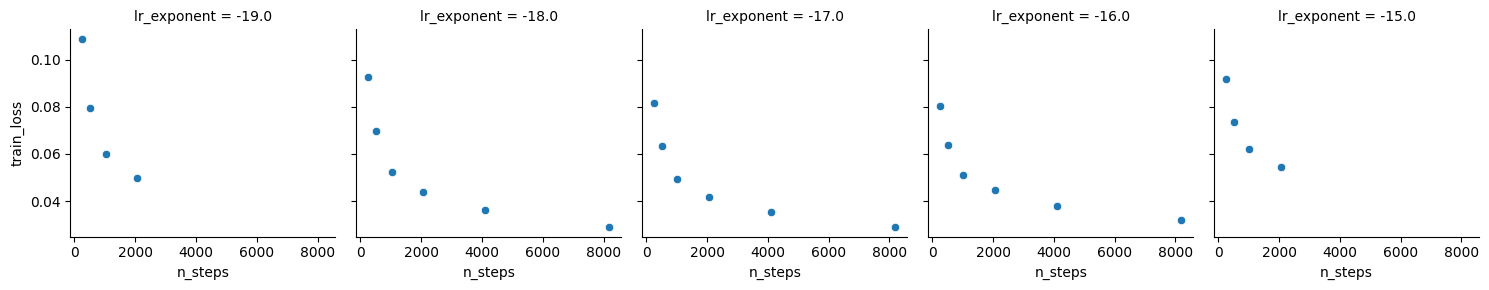

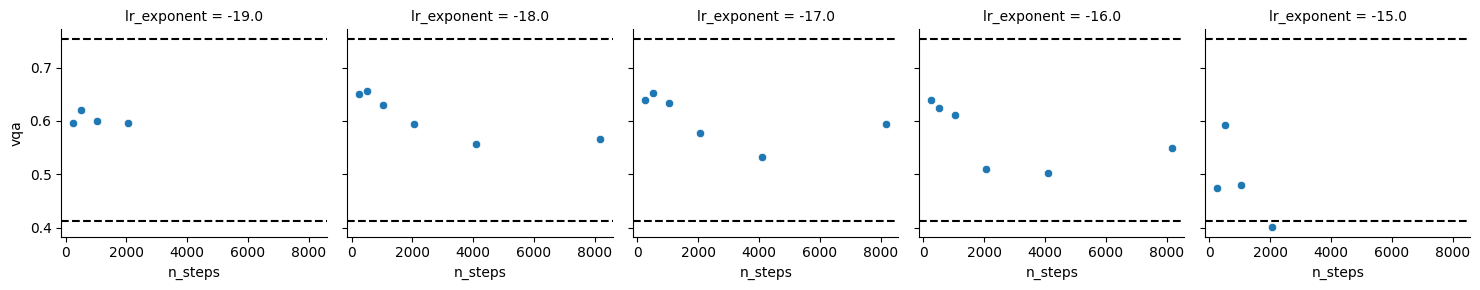

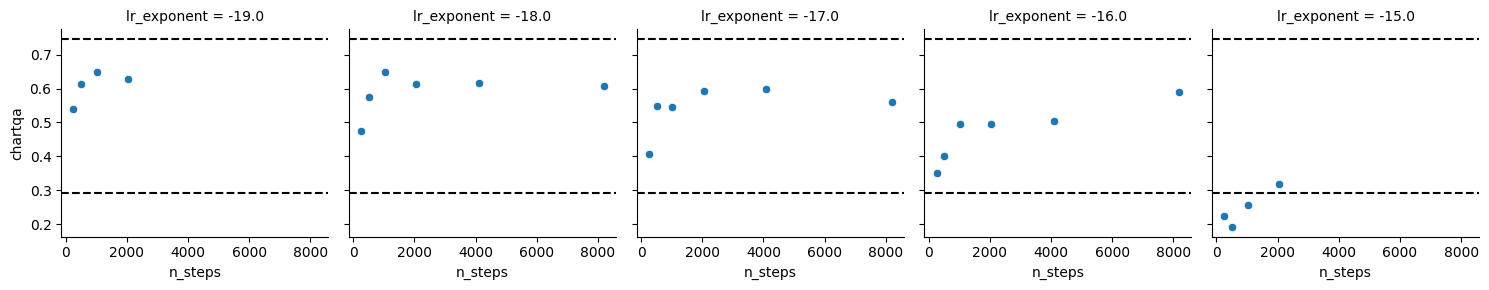

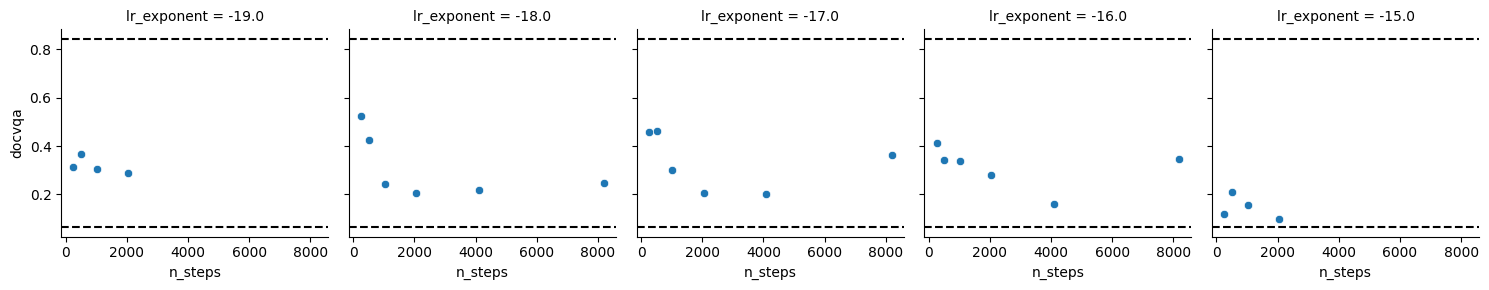

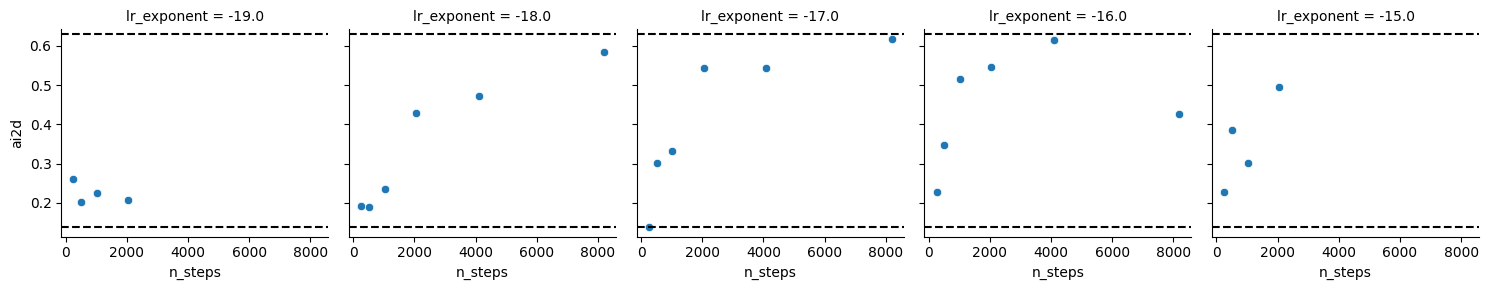

In [9]:
g = sns.relplot(data=df, x="n_steps", y="train_loss", col="lr_exponent", height=3)

tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
for task in tasks:
    g = sns.relplot(data=df, x="n_steps", y=task, col="lr_exponent", height=3)
    for ax in g.axes.flat:
        ax.axhline(step_0[task][0], linestyle="--", color="black")
        ax.axhline(baseline[task][0], linestyle="--", color="black")

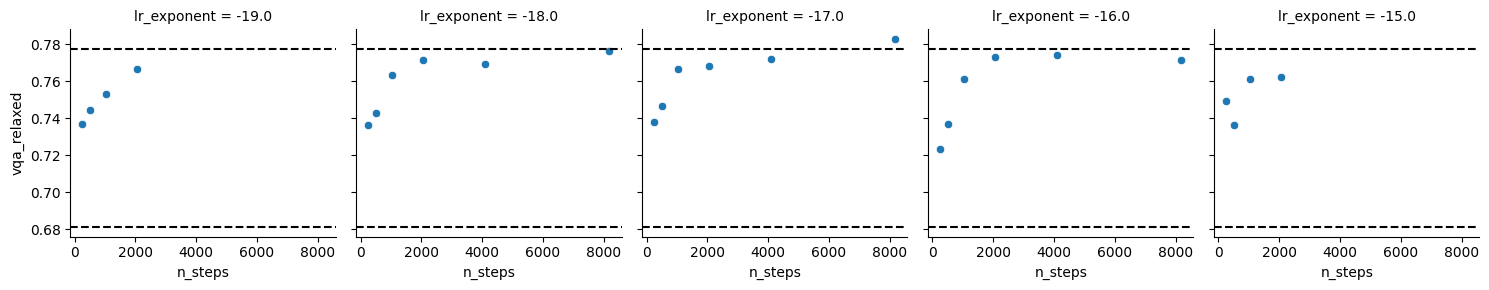

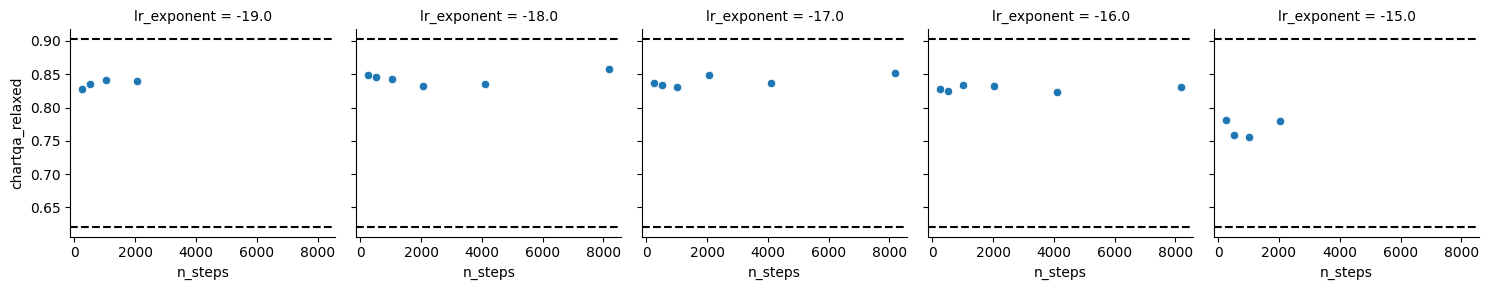

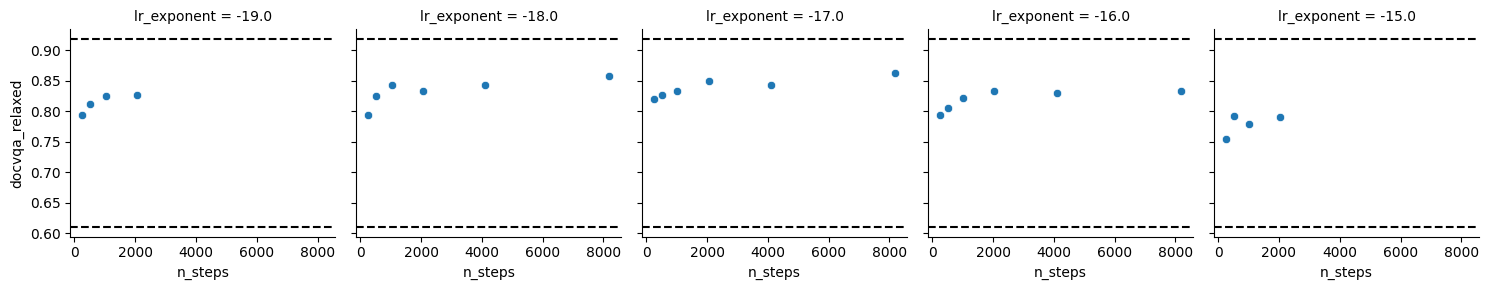

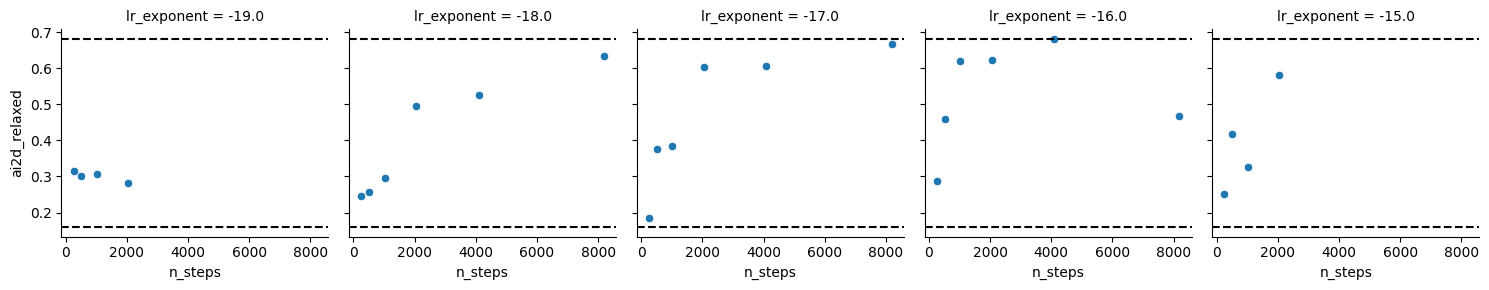

In [10]:
tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
for task in tasks:
    g = sns.relplot(data=df, x="n_steps", y=f"{task}_relaxed", col="lr_exponent", height=3)
    for ax in g.axes.flat:
        ax.axhline(step_0[task][1], linestyle="--", color="black")
        ax.axhline(baseline[task][1], linestyle="--", color="black")

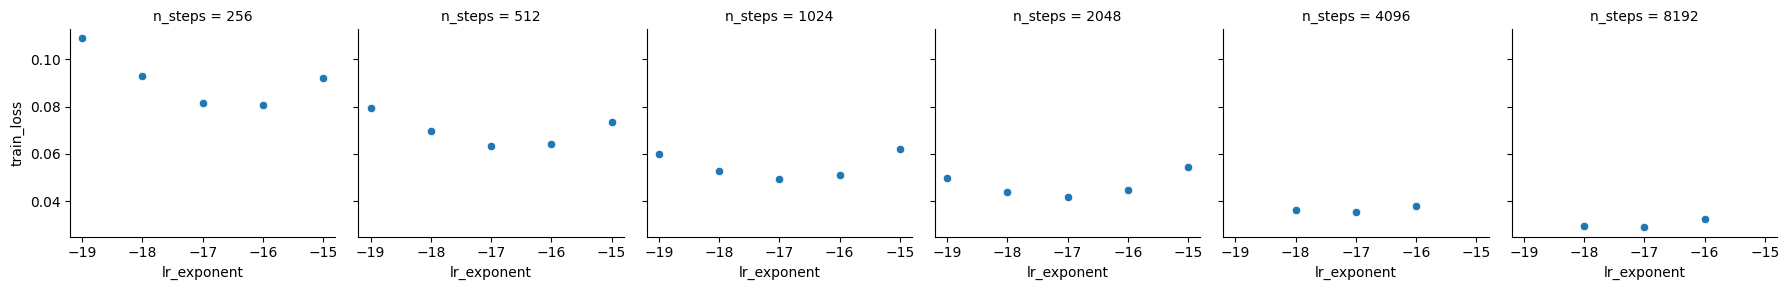

In [11]:
sns.relplot(data=df, x="lr_exponent", y="train_loss", col="n_steps", height=3)

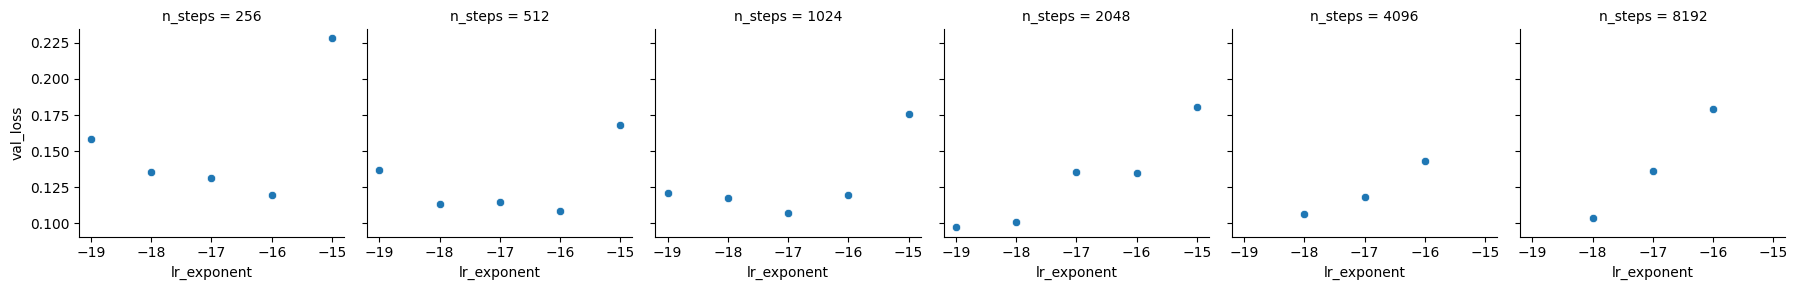

In [12]:
sns.relplot(data=df, x="lr_exponent", y="val_loss", col="n_steps", height=3)